### Filtering and Signal Smoothing Project

Name: Hart Williams

### Overview

This assignment focuses on concepts in filtering continuous signals with examples of noise removal and signal detection.

### Learning objectives
- explain how a filtering is a model of linear system
- explain the assumptions of linearity and time-invariance
- derive a recursive filter to implement a moving average
- explain the different between and IIR and an FIR filter
- implement a one dimensional IIR filter
- implement the operation of convolution
- implement low-, high-, and band-pass filters
- explain the impulse response function
- apply filters to different types of signals
- use a filter to detect continuous signals in noise

***
## Exercises

### 1. Filtering

Filtering is a model of how a system responds to a signal.  The goal is not only to describe the relationship between the input and output, but also to design the characteristics of system itself so that it produces desired outputs.  The input output relationship is not just an instantaneous function of time, e.g. $y(t) = f(x(t))$.  Instead, filtering can be described as a transformation of one signal to another.  We will see below that the response of the system can be characterized by the function $h[n]$.  It is common to represent the flow of the signal through the system with a block diagram:

<img src="tikz/system-block-diagram.svg">

### 1a. A moving average filter

One of the simplest computations to perform is an average, to do, for example, noise reduction.  A system that outputs (in discrete steps) the average of the last $M$ samples is described mathematically by
$$
y_M[n] = \frac{1}{M} \sum_{k=0}^{M-1} x[n-k]
$$
To implement this in a physical system would seem to require a memory of the previous $M-1$ input values, but it is possible to do the equivalent computation simply by using feedback, i.e. the previous output.  In terms of a block diagram, we can represent the signal flow in terms of a feed-forward part and a feed-back part.

Use the equation above to derive the following expression
$$
y_M[n] = \frac{1}{M} \sum_{k=0}^{M-1} x[n-k]
$$
Then make an approximation to get
$$
y[n] = \lambda y[n-1] + (1-\lambda) x[n]
$$
This is now a just a function of the current input and the previous output, so the filter can be described as a simple feedback system.  What is the behavior for different values of $\lambda$?

This equation can be represented in a diagram:

<img src="tikz/moving-average-filter.svg">

The paths represent the signal flow and the  nodes represent the operations (multiplication, addition, and delay).  Notice how the output is feedback and added (after scaling) to the scaled input.  $z^{-1}$ is standard notation for representing a delay of one sample (for reasons that go beyond the scope of this course, but it's from the time shift property of the z-transform).  This is also just a memory cell that holds the last value of the output, i.e. $y[n-1]$.

# Answer for 1a)
* A system that outputs (in discrete steps) the average of the last $M$ samples is described mathematically by:
$$
y_M[n] = \frac{1}{M} \sum_{k=0}^{M-1} x[n-k]
$$
* We first rewrite $y_{m-1}[n-1]$, which is the moving average of the last $M-1$ samples up to $n-1$:
$$
y_{M-1}[n-1] = \frac{1}{M-1} \sum_{k=0}^{M-2} x[n-1-k]
$$
* Now, using the definition of $y_M[n]$, we express it in terms of $y_{M-1}[n-1]$:
$$
y_M[n] = \frac{1}{M} \left( x[n] + \sum_{k=1}^{M-1} x[n-k] \right)
$$
* Rewriting the summation term using $y_{M-1}[n-1]$:
$$
y_M[n] = \frac{1}{M} \left( x[n] + (M-1) y_{M-1}[n-1] \right)
$$
* Factoring:
$$
y_M[n] = \left( \frac{M-1}{M} \right) y_{M-1}[n-1] + \left( \frac{1}{M} \right) x[n]
$$
* Defining $\lambda = \frac{M-1}{M}$, we obtain:
$$
y_M[n] = \lambda y_{M-1}[n-1] + (1-\lambda) x[n]
$$
* For large $M$, we approximate $M-1 \approx M$, making $\lambda$ approximately constant.
$$
y[n] \approx \lambda y[n-1] + (1-\lambda) x[n]
$$

This equation now expresses the filtered output as a function of the current input and the previous output, forming a simple feedback system.
* If $\lambda \approx 1$ (i.e. M is large), the output changes slowly, emphasizing past values. This results in strong smoothing or low-pass filtering.
* If $\lambda$ is small, the output reacts too quickly to new inputs, making the filter less smooth.
* If $\lambda = 0$, the filter is not recursive, and the output is just the input itself ($y[n] = x[n]$).
* If $\lambda$ is close to but not exactly 1, the filter behaves like an exponential moving average, giving recent inputs slightly more influence while preserving past data.

Overall, by tuning $\lambda$, one can control the trade-off between smoothing and responsiveness in the filtering process.

### 1b. Implementation

Write a function `movingavg(x; λ=0.5)` which takes a vector `x` and returns the moving average as described above.  Assume that the input `x` is zero before the first sample.

To test your function, we could use just random noise, but we can make it a little more interesting by smoothing a random process.  Write a function `randprocess(N; σ=1)` which produces a waveform of length `N` where the next sample is randomly perturbed from the previous according to
$$
x_i \sim \mathcal{N}(x_{i-1}, \sigma)
$$
Note that this isn't a function of time, only the previous sample.  

Show an examples of random process vector `x`  with the waveform resulting from different values $\lambda$.  Use your code from A3a to generate a noisy sine wave, and demonstrate how the moving average smooths the signal.

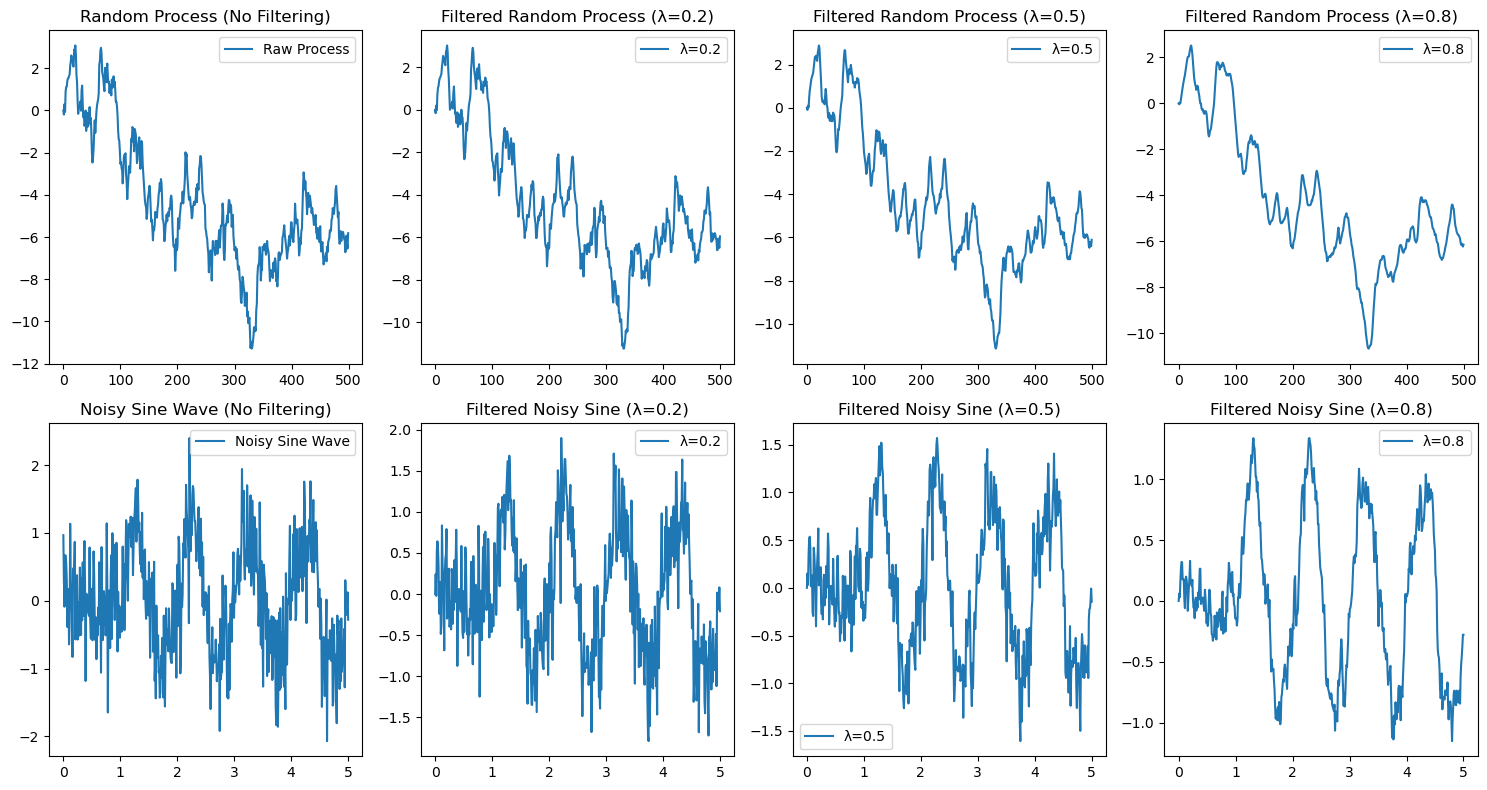

In [132]:
import numpy as np
import matplotlib.pyplot as plt

''' Code from A3a '''
# Generate values for a sine wave with frequency f and phase delay d (in seconds)
def sinewave(t, f=1.0, d=0.0):
    adjusted_t = t - d
    return np.sin(2 * np.pi * f * adjusted_t)

# Generate values at time t of a signal defined by function g(t), along with delay τ (in sec) and duration T (in sec)
def gensignal(t, g, τ, T):
    t = np.asarray(t)
    g_vec = np.vectorize(g)
    return np.where((t >= τ) & (t < T + τ), g_vec(t - τ), 0)

# Generate a noisy version of a given signal g, where σ specifies the standard deviation of the noise
def noisysignal(t, g, τ, T, σ):
    signal = gensignal(t=t, g=g, τ=τ, T=T)
    noise = np.random.normal(0, σ, size=np.shape(signal))
    return signal + noise


''' Now for new code '''
# Compute the moving average of a signal using the recursive formula: y[n] = λ * y[n-1] + (1-λ) * x[n]
def movingavg(x, λ=0.5):
    y = np.zeros_like(x)
    for n in range(1, len(x)):
        y[n] = λ * y[n-1] + (1-λ) * x[n]
    return y

# Generate a random process where each sample is normally distributed around the previous sample with standard deviation σ
def randprocess(N, σ=1):
    x = np.zeros(N)
    for i in range(1, N):
        x[i] = np.random.normal(x[i-1], σ)
    return x

# Generate test signals
N = 500
t = np.linspace(0, 5, N)
σ = 0.5
x_random = randprocess(N, σ=σ)
x_noisy_sine = noisysignal(t, sinewave, τ=1, T=4, σ=σ)

# Apply moving average with different λ values
λ_values = [0.2, 0.5, 0.8]
filtered_signals_random = [movingavg(x_random, λ) for λ in λ_values]
filtered_signals_sine = [movingavg(x_noisy_sine, λ) for λ in λ_values]

# Plot results
fig, axes = plt.subplots(2, len(λ_values) + 1, figsize=(15, 8))

# Plot raw random process
axes[0, 0].plot(x_random, label="Raw Process")
axes[0, 0].set_title("Random Process (No Filtering)")
axes[0, 0].legend()

# Plot filtered random processes
for i, λ in enumerate(λ_values):
    axes[0, i + 1].plot(filtered_signals_random[i], label=f"λ={λ}")
    axes[0, i + 1].set_title(f"Filtered Random Process (λ={λ})")
    axes[0, i + 1].legend()

# Plot raw noisy sine wave
axes[1, 0].plot(t, x_noisy_sine, label="Noisy Sine Wave")
axes[1, 0].set_title("Noisy Sine Wave (No Filtering)")
axes[1, 0].legend()

# Plot filtered noisy sine waves
for i, λ in enumerate(λ_values):
    axes[1, i + 1].plot(t, filtered_signals_sine[i], label=f"λ={λ}")
    axes[1, i + 1].set_title(f"Filtered Noisy Sine (λ={λ})")
    axes[1, i + 1].legend()

plt.tight_layout()
plt.show()

# Explanation for 1b:
* The top row of plots shows a random process, where each sample is randomly perturbed from the previous one. The unfiltered process is on the left, and the progressively smoothed versions (with different values of $\lambda$) are to the right.
* The bottom row of plots shows a noisy sine wave. Again, the unfiltered version is on the left, and the smoothed versions are on the right.

**Observations:**
* A lower $\lambda$ results in a less smooth output, retaining more of the original variations. In contrast, a higher $\lambda$ results in stronger smoothing, reducing noise but lagging behind rapid changes in the signal.
* For the noisy sine wave, higher $\lambda$ values effectively remove much of the high-frequency noise, making the underlying sine wave much clearer.

### 1c. System delay
You will notice that the filtered waveform is not exactly superimposed on the noisy signal.  Why is that?  What can you say about the response lag?  Plot smoothed noisy sine waves again, but this time with delay adjusted for a centered average.

* The filtered waveform does not perfectly align with the noisy signal due to response lag, which is an inherent characteristic of moving average filters, especially in recursive implementations. This lag occurs because the filter depends on previous values, effectively "delaying" rapid changes in the input signal.
* The larger the value of $\lambda$, the stronger the smoothing effect, but also the greater the lag.
* The filter behaves like a low-pass filter, suppressing high-frequency variations (noise) but also causing a phase shift.

**Adjusting for the Lag**
* To reduce the misalignment, we can compensate for the lag by applying an approximate delay correction. For an exponential moving average (EMA) like ours, the effective delay can be approximated by:
$$
Delay \approx \left(\frac{1}{1-\lambda}\right)
$$
* Using this delay, we can shift back the smoothed signal to better align it with the original noisy sine wave.

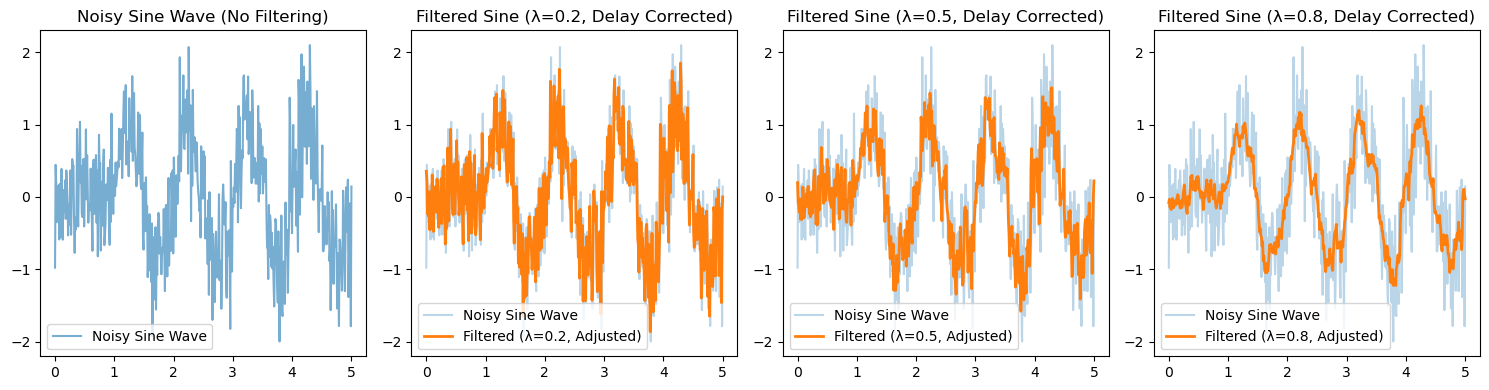

In [136]:
# Shift the smoothed signal back by an approximate delay of 1/(1-λ)
def adjust_for_delay(y, λ):
    delay = int(round(1 / (1 - λ)))  # Approximate lag in samples
    return np.roll(y, -delay)        # Shift left to compensate for delay

# Generate noisy sine wave
x_noisy_sine = noisysignal(t, sinewave, τ=1, T=4, σ=σ)

# Apply moving average with different λ values
λ_values = [0.2, 0.5, 0.8]
filtered_signals_sine_adjusted = [
    adjust_for_delay(movingavg(x_noisy_sine, λ), λ) for λ in λ_values
]

# Plot the adjusted filtered sine waves
fig, axes = plt.subplots(1, len(λ_values) + 1, figsize=(15, 4))

# Plot raw noisy sine wave
axes[0].plot(t, x_noisy_sine, label="Noisy Sine Wave", alpha=0.6)
axes[0].set_title("Noisy Sine Wave (No Filtering)")
axes[0].legend()

# Plot delay-adjusted filtered sine waves
for i, λ in enumerate(λ_values):
    axes[i + 1].plot(t, x_noisy_sine, label="Noisy Sine Wave", alpha=0.3)
    axes[i + 1].plot(t, filtered_signals_sine_adjusted[i], label=f"Filtered (λ={λ}, Adjusted)", linewidth=2)
    axes[i + 1].set_title(f"Filtered Sine (λ={λ}, Delay Corrected)")
    axes[i + 1].legend()

plt.tight_layout()
plt.show()

# Continued expalantion for 1c:
* The leftmost plot shows the original noisy sine wave without filtering.
* The three rightmost plots show the filtered signals for different values of $\lambda$, but now with the delay adjusted.

**Observations:**
* By shifting the signal back using an approximate delay of $\left(\frac{1}{1-\lambda}\right)$, they now align better with the original waveform.
* Larger $\lambda$ values still smooth the signal more aggressively, but they no longer lag as much behind the true sine wave.

### 2. IIR filters

#### First order IIR filter

We can generalize the filter above to be a function of both the previous output and the previous input.  In addition, we can have arbitrary values for the multiplicative factors (coefficients).

$$
y[n] =  a_1 y[n-1] + b_0 x[n] + b_1 x[n-1]
$$

It can be represented with the following block diagram

<img src="tikz/first-order-IIR-filter.svg">

This is a simple case of a general class of filters called "IIR filters" for infinite impulse response, which these filters have due to the feedback.  Different settings of the parameters will result in different response properties.  This particular example is called a first order IIR filter, because it's response can be characterized as a ratio of first order polynomials.  That analysis is beyond the scope of this course (and is actually a whole course in itself), so here we will just focus on a few examples and their basic response properties.

#### Second order IIR filter

A second-order IIR filter is defined by the equation
$$
y[n] = a_1 y[n-1] + a_2 y[n-2] + b_0 x[n] + b_1 x[n-1] + b_2 x[n-2]
$$
It adds a second set of delays and coefficients and can be characterized by a ratio of second order polynomials.  The block diagram is

<img src="tikz/second-order-IIR-filter.svg">

#### General IIR difference equation

The standard form of the general $nth$ order constant coefficient difference equation is
$$
\sum_{k=0}^{N-1} a_k y[n-k] = \sum_{k=0}^{M-1} b_k x[n-k]
$$

Usually it is assumed that $a_0 = 1$, and re-written in the form
$$
y[n] = \sum_{k=0}^{M-1} b_k x[n-k] - \sum_{k=1}^{N-1} a_k y[n-k]
$$
Note that in the second sum now starts at $k=1$.  This might seem backwards, but it's the standard, and when there's a standard it behooves you to follow it. So, note that the signs of the $a_k$ coefficients have changed sign from the 1st and 2nd order equations above.  A saving grace is that this form avoids minus signs in the spectral analysis equations, but we won't cover that here.

### 2a. Implementation

Write a function `filterIIR(x; a, b)` which accepts coefficient vectors `a` and `b` of arbitrary length, with the vector `a` starting at $a_1$ and the vector `b` starting at $b_0$.  It should return an output that is the same length as the input.  Assume that the input waveform prior to the first value was zero.  Show that your function reproduces the output from the moving average filter.

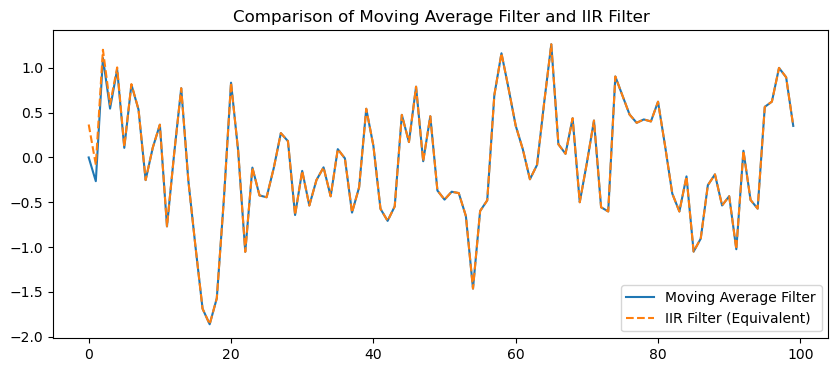

In [205]:
# Implements an IIR filter given input (signal) x and coefficient vectors a and b.
# Returns an output the same length as the input.
# a[0] is assumed to be 1. 
def filterIIR(x, a, b):
    N = len(a)
    M = len(b)
    y = np.zeros_like(x)

    for n in range(len(x)):
        # Compute feedforward part
        y[n] += sum(b[k] * x[n-k] if n-k >= 0 else 0 for k in range(M))
        # Compute feedback part
        y[n] -= sum(a[k] * y[n-k] if n-k >= 0 else 0 for k in range(1, N))  # Start from k=1
    
    return y


# Test with the moving average filter parameters
λ = 0.5
a_test = [1, -λ]  # Equivalent to y[n] = λ*y[n-1] + (1-λ)*x[n]
b_test = [1-λ]

# Generate test signal
x_test = np.random.randn(100)  # Random noise as input
y_IIR = filterIIR(x_test, a_test, b_test)
y_MA = movingavg(x_test, λ)  # Moving average reference

# Plot comparison
plt.figure(figsize=(10, 4))
plt.plot(y_MA, label="Moving Average Filter")
plt.plot(y_IIR, '--', label="IIR Filter (Equivalent)")
plt.legend()
plt.title("Comparison of Moving Average Filter and IIR Filter")
plt.show()

# Explanation for 2a:
The solid line (moving average) and the dashed line (IIR filter) are almost identical, verifying correctness. This demonstrates that a simple moving average is a special case of an IIR filter.

### 2b. First order low- and high-pass IIR filters

Use your function above to implement two filters with the coefficients $a = [-0.9]$ and $b = [0.1]$.  Illustrate the filter by applying it to a random process waveform and overlaying the filter output on the input.  

We can think of waveforms as being composed of a spectrum of frequencies, i.e. the sum of oscillations of different frequencies.  A speech waveform, for example, might be composed of a small number of frequencies, and so it is a more compact way to describe the structure in the signal than the time-varying waveform.  We will see later how to compute the spectral representation for arbitrary signals.  In this example, we can think of the random process as being composed of a large set of frequencies, with rapid variations characterized by higher frequencies and slower variations by lower frequencies.

This filter setting is an example of a **low-pass filter**, because it passes the lower frequency components while filtering out the higher frequencies.

Now use the coefficients $a = [0.9]$ and $b = [0.1]$ and contrast the effect by applying it to the same waveform.  This is an example of a **high-pass filter** because it passes the higher frequency components and filters out the lower frequencies.

Contrast the first order difference equations of these two filters.  How is each achieving the result?

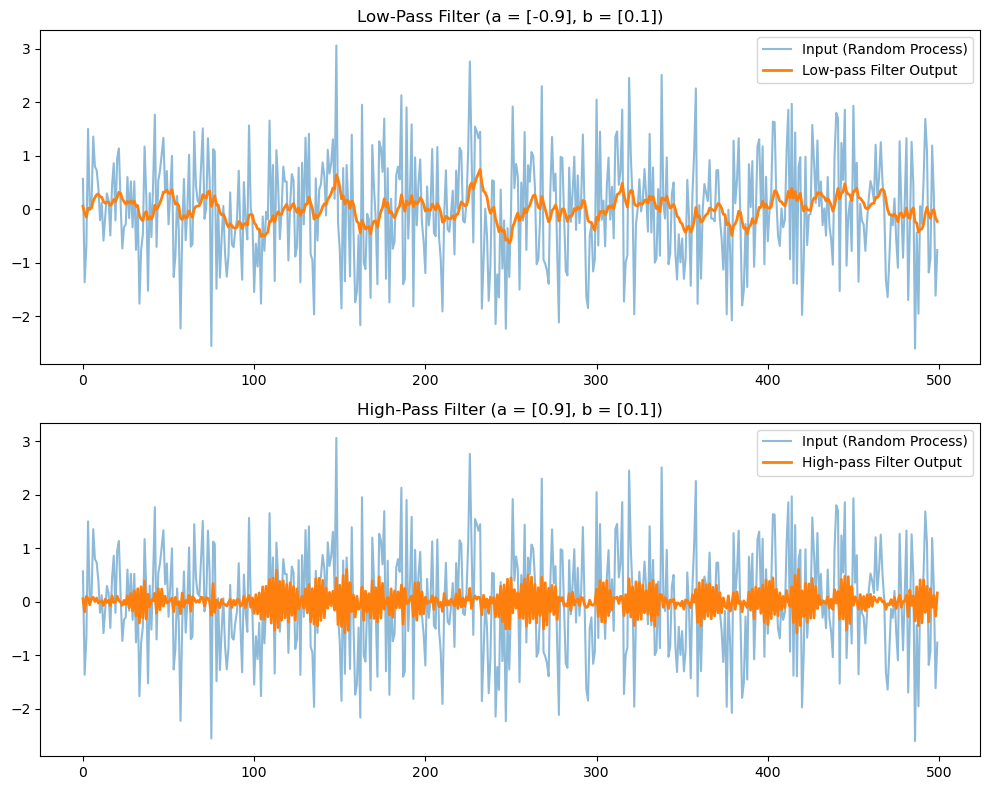

In [149]:
# Generate a random process
N = 500
σ = 1
x_random = np.random.randn(N)  # Random noise as input

# Define low-pass filter coefficients
a_lowpass = [-0.9]  # Corresponds to y[n] = 0.9 * y[n-1] + 0.1 * x[n]
b_lowpass = [0.1]

# Define high-pass filter coefficients
a_highpass = [0.9]  # Corresponds to y[n] = -0.9 * y[n-1] + 0.1 * x[n]
b_highpass = [0.1]

# Apply filters
y_lowpass = filterIIR(x_random, [1] + a_lowpass, b_lowpass)
y_highpass = filterIIR(x_random, [1] + a_highpass, b_highpass)

# Plot the results
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

# Low-pass filter response
axes[0].plot(x_random, label="Input (Random Process)", alpha=0.5)
axes[0].plot(y_lowpass, label="Low-pass Filter Output", linewidth=2)
axes[0].set_title("Low-Pass Filter (a = [-0.9], b = [0.1])")
axes[0].legend()

# High-pass filter response
axes[1].plot(x_random, label="Input (Random Process)", alpha=0.5)
axes[1].plot(y_highpass, label="High-pass Filter Output", linewidth=2)
axes[1].set_title("High-Pass Filter (a = [0.9], b = [0.1])")
axes[1].legend()

plt.tight_layout()
plt.show()

# Explanation for 2b:
**Observations:**
1. Low-Pass Filter $(a = [-0.9], b = [0.1])$
* This filter smooths the input signal by surpressing rapid changes (high-frequency components) while preserving slower variations.
* The output is much less "jumpy" than the input, confirming that high-frequency noise is being attenuated.
2. High-Pass Filter $(a = [0.9], b = [0.1])$
* This filter emphasizes rapid changes, making it more sensitive to high-frequency components.
* The output looks more jagged than the original signal, highlighting rapid fluctuations while filtering out low-frequency trends.
  
**Why does this happen?**

The low-pass filter equation has the form:
$$
y[n] = 0.9y[n-1] + 0.1x[n]
$$
* The term $0.9y[n-1]$ means the output is strongly influenced by its previous values.
* The small weight on $x[n]$ means new inputs have a limited immediate impact, further contributing to smoothing.
  
The high-pass filter equation has the form:
$$
y[n] = -0.9y[n-1] + 0.1x[n]
$$
* The negative feedback term ($-0.9y[n-1]$) reverses the smoothing effect by enhancing changes rather than continuity.
* This causes the filter to react strongly to rapid changes, making it more sensitive to high frequencies.

### 2c. Second order bandpass filters

Illustrate the filtering a signal composed of uniform random noise on $[-1, 1]$ using the following coefficients
$$
\begin{aligned}
a &= [-1.265, 0.81] \\
b &= [0.135]
\end{aligned}
$$

Now do the same for the following coefficients
$$
\begin{aligned}
a &= [-1.702, 0.81] \\
b &= [0.063]
\end{aligned}
$$

What you should see is that these 2nd order filters filter out both the low and the high frequency components.  These are called **bandpass** filters.  Contrast the two IIR difference equations and provide an interpretation of how they are computing the result.

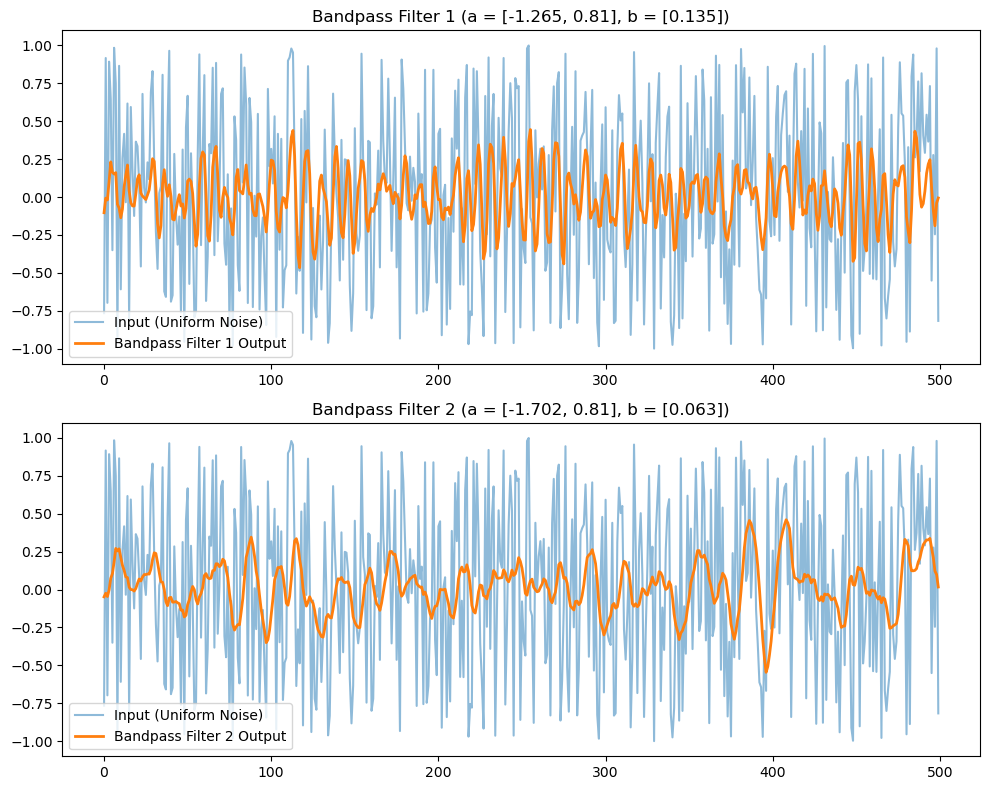

In [152]:
# Generate a uniform random noise signal on [-1, 1]
N = 500
x_uniform = np.random.uniform(-1, 1, N)

# Define first bandpass filter coefficients
a_bandpass1 = [-1.265, 0.81]
b_bandpass1 = [0.135]

# Define second bandpass filter coefficients
a_bandpass2 = [-1.702, 0.81]
b_bandpass2 = [0.063]

# Apply bandpass filters
y_bandpass1 = filterIIR(x_uniform, [1] + a_bandpass1, b_bandpass1)
y_bandpass2 = filterIIR(x_uniform, [1] + a_bandpass2, b_bandpass2)

# Plot the results
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

# First bandpass filter response
axes[0].plot(x_uniform, label="Input (Uniform Noise)", alpha=0.5)
axes[0].plot(y_bandpass1, label="Bandpass Filter 1 Output", linewidth=2)
axes[0].set_title("Bandpass Filter 1 (a = [-1.265, 0.81], b = [0.135])")
axes[0].legend()

# Second bandpass filter response
axes[1].plot(x_uniform, label="Input (Uniform Noise)", alpha=0.5)
axes[1].plot(y_bandpass2, label="Bandpass Filter 2 Output", linewidth=2)
axes[1].set_title("Bandpass Filter 2 (a = [-1.702, 0.81], b = [0.063])")
axes[1].legend()

plt.tight_layout()
plt.show()

# Explanation for 2c:
**Observations:**
1. Both filters remove high-frequency noise and low-frequency trends, preserving only mid-range frequencies. This is the behavior of a bandpass filter.
2. Filter 1 ($a=[-1.265,0.81], b=[0.135]$):
* The output oscillates more smoothly.
* This filter allows a slightly wider range of frequencies to come through.
* The larger b-coefficient (0.135) means new inputs have a greater immediate effect on the output.
3. Filter 2 ($a=[-1.702,0.81], b=[0.063]$):
* The output oscillates more sharply.
* The lower b-coefficient (0.063) means the new input has a smaller immediate effect, making the response more dependent on past values.
* The stronger feedback terms suppress both high and low frequencies more aggressively.

**Interpreting the IIR Difference Equations:**
* The general form:
$$
y[n] = b_0x[n] - a_1y[n-1] - a_2y[n-2]
$$
* The feedback coefficients $a_1$ and $a_2$ control how much influence past outputs have.
  * Larger |$a_1$| values introduce more oscillatory behavior.
  * The $a_2$ term adds a second level of feedback, reinforcing specific frequencies.
* The feedforward coefficient $b_0$ controls the weight of the current input.
  * A larger $b_0$ allows the input to have a more immediate effect.
  * A smaller $b_0$ smooths out rapid variations, emphasizing frequencies that persist.

**Why are these Bandpass filters?**
* High-pass behavior: The feedback structure cancels out low-frequency variations, preventing slow trends from dominating the signal.
* Low-pass behavior: The interaction of the feedback terms also cancels out at very high frequencies, preventing rapid oscillations.
* Middle frequencies pass through: The filter is tuned to allow only specific intermediate frequencies to remain.

### 2d. Characterizing the filter response

We have seen how filtering can process the signal to smooth it or remove low-frequency variation.  Here we want to focus on this question: If we are given an unknown system, how would we characterize its response?  Is there a way to measure the input-output relationship in a systematic way?

We will discuss the analytic methods for this at a future point in the course.  Here, we simply want to develop some intuition.  Generate a noisy sine wave like above using a sampling frequency of 2 kHz and a signal duration of 100 msecs.  Using the filter coefficients in 2c, make a figure consisting of a 4x4 matrix of plots in which you vary the frequency (from low to high) over the rows and the noise level (from high to low) over the columns. Make sure that the y-axes have the same limits, an try to choose frequencies that contrast the responses.  Make one plot each for the two sets of filter coefficients in 2c.

What can you observe about the relation between the output an input?

Now make a plot where you systematically vary an input frequency (without noise) from 0 to the Nyquist frequency.  Plot of the output signal power as a function of frequency.  How would you characterize the system response?

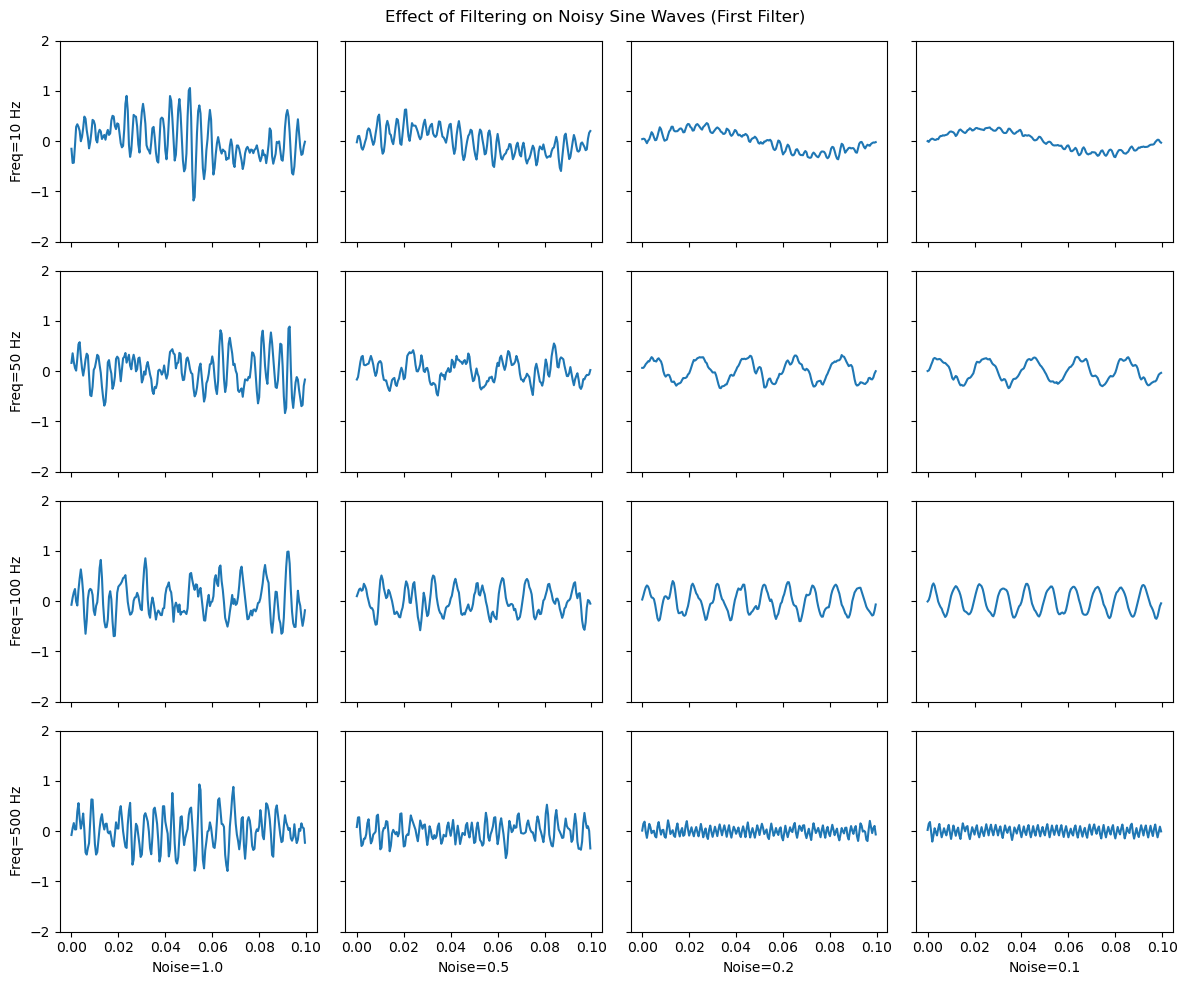

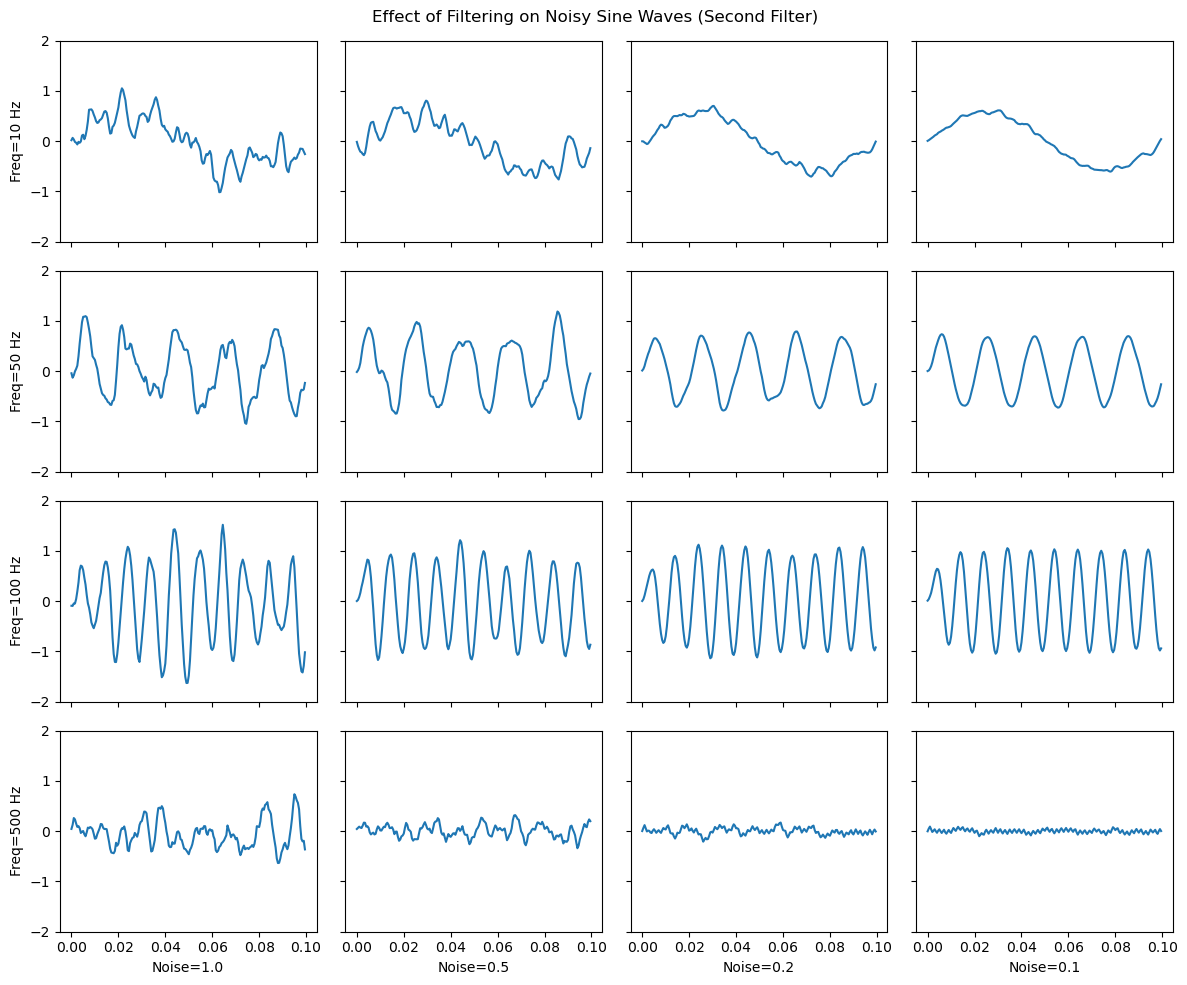

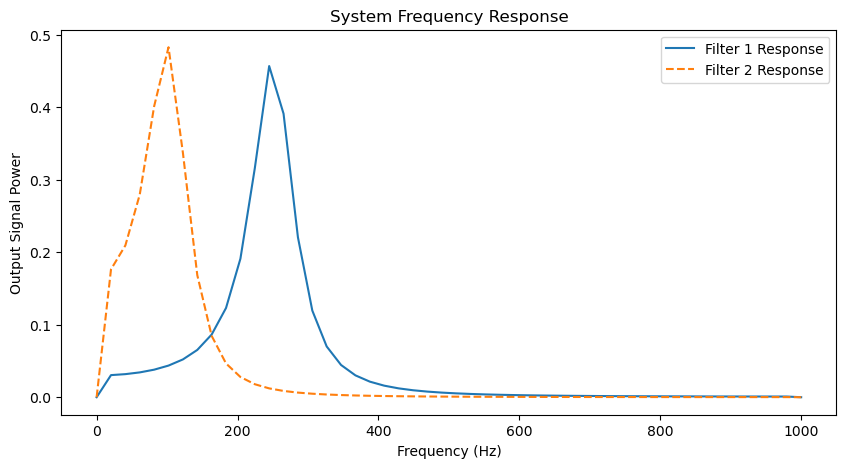

In [155]:
# Define filter coefficients
a_bandpass1 = [-1.265, 0.81]
b_bandpass1 = [0.135]

a_bandpass2 = [-1.702, 0.81]
b_bandpass2 = [0.063]

# Define parameters for the sine wave
fs = 2000  # Sampling frequency (2 kHz)
duration = 0.1  # Signal duration (100 ms)
t = np.linspace(0, duration, int(fs * duration), endpoint=False)  # Time vector

# Define frequency and noise level ranges
frequencies = [10, 50, 100, 500]  # Low to high frequencies
noise_levels = [1.0, 0.5, 0.2, 0.1]  # High to low noise levels

# Generate and filter sine waves for both sets of filter coefficients
fig, axes = plt.subplots(4, 4, figsize=(12, 10), sharey=True, sharex=True)
fig.suptitle("Effect of Filtering on Noisy Sine Waves (First Filter)")

for i, f in enumerate(frequencies):
    for j, noise in enumerate(noise_levels):
        x_noisy_sine = np.sin(2 * np.pi * f * t) + np.random.normal(0, noise, len(t))
        y_filtered = filterIIR(x_noisy_sine, [1] + a_bandpass1, b_bandpass1)

        ax = axes[i, j]
        ax.plot(t, y_filtered, label=f"f={f} Hz, noise={noise}")
        ax.set_ylim(-2, 2)
        if i == 3:
            ax.set_xlabel(f"Noise={noise}")
        if j == 0:
            ax.set_ylabel(f"Freq={f} Hz")

plt.tight_layout()
plt.show()

# Repeat for the second filter
fig, axes = plt.subplots(4, 4, figsize=(12, 10), sharey=True, sharex=True)
fig.suptitle("Effect of Filtering on Noisy Sine Waves (Second Filter)")

for i, f in enumerate(frequencies):
    for j, noise in enumerate(noise_levels):
        x_noisy_sine = np.sin(2 * np.pi * f * t) + np.random.normal(0, noise, len(t))
        y_filtered = filterIIR(x_noisy_sine, [1] + a_bandpass2, b_bandpass2)

        ax = axes[i, j]
        ax.plot(t, y_filtered, label=f"f={f} Hz, noise={noise}")
        ax.set_ylim(-2, 2)
        if i == 3:
            ax.set_xlabel(f"Noise={noise}")
        if j == 0:
            ax.set_ylabel(f"Freq={f} Hz")

plt.tight_layout()
plt.show()

# Systematic frequency sweep and power computation
freq_sweep = np.linspace(0, fs/2, 50)  # 0 to Nyquist frequency (1 kHz)
power_response_1 = []
power_response_2 = []

for f in freq_sweep:
    x_pure_sine = np.sin(2 * np.pi * f * t)  # Pure sine wave
    y_filtered1 = filterIIR(x_pure_sine, [1] + a_bandpass1, b_bandpass1)
    y_filtered2 = filterIIR(x_pure_sine, [1] + a_bandpass2, b_bandpass2)
    
    # Compute signal power (mean squared amplitude)
    power_response_1.append(np.mean(y_filtered1 ** 2))
    power_response_2.append(np.mean(y_filtered2 ** 2))

# Plot system response
plt.figure(figsize=(10, 5))
plt.plot(freq_sweep, power_response_1, label="Filter 1 Response")
plt.plot(freq_sweep, power_response_2, label="Filter 2 Response", linestyle="dashed")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Output Signal Power")
plt.title("System Frequency Response")
plt.legend()
plt.show()

# Explanation for 2d:

### Observations:
**Noisy Sine Wave Filtering**
1. Low-frequency sine waves (first rows) are preserved better than high-frequency waves.
2. As noise decreases (rightward in columns), the filtered signals become smoother and more structured.
3. Filter 1 vs Filter 2:
* Filter 1 ($a=[-1.265,0.81], b=[0.135]$) allows a broader range of frequencies through.
* Filter 2 ($a=[-1.702,0.81], b=[0.063]$) has a narrower passband, meaning it filters out more frequencies.
  
**System Frequency Response (Output Power vs Frequency)**
* The frequency plot shows bandpass characteristics:
  * Both filters allow a certain range of frequencies to pass while attenuating lower and higher frequencies.
  * Filter 2 has a more selective response, passing only a narrow set of frequencies.
  * Filter 1 has a slightly wider passband, allowing a broader range of mid-range frequencies.

### How to Characterize the System Response: ###
* By sweeping a pure sine wave input across a range of frequencies and measuring output power, we can empirically derive the system's frequency response.
* The resulting plots reveal that these filters suppress low and high frequencies, behaving as bandpass filters.

### 3. The impulse response function

<img src="tikz/system-block-diagram.svg">

The essential property of linear time-invariant (LTI)systems is that it is possible to predict the system response $y[n]$ to *any* input $x[n]$ using just a single function, called the *impulse response function*.  Naturally, this is derived assuming properties of linearity and time-invariance.  Here we assume the response of the system is determined by $\mathcal{H}$

$$
y[n] = \mathcal{H}(x[n])
$$

Note that this does not imply the $nth$ sample of the output is a function of only the $nth$ sample of the input.  As we have seen above, the output of an $nth$ order system is a function of the previous $n$ samples.  

Here, we have use a common but notationally imprecise shorthand, i.e. using $x[n]$ to refer to the whole waveform and also the value of that waveform at the $nth$ sample.  This is analogous to what we mean when we use $f(t)$ to refer to both the function $f$ or its value at time $t$, depending on the context.  Analogous to when we say the function $f(t)$ we say the sequence $x[n]$.

#### Linearity

The assumption that the system is linear means
$$
\mathcal{H}(\alpha x_1[n] + \beta x_2[n]) 
= \alpha\mathcal{H}(x_1[n]) + \beta\mathcal{H}(x_2[n])
$$

This is also called the principle of superposition.  This can be generalized to the superposition of many inputs.  If
$$
x[n] = \sum_k \alpha_k x_k[n]
$$
and the individual system responses are
$$
y_k[n] = \mathcal{H}(x_k[n])
$$
then the output will be the superposition of the individual responses
$$
y[n] = \sum_k \alpha_k y_k[n]
$$

The assumptions of linearity is natural for sounds since sound pressure is additive.  It also works for electrical circuits since both voltage and current are also additive.  For images, however, the assumption of linearity can be questioned.  The property of occlusion means that the representation of two objects is not the same as the addition of their individual representations.  Images might be invariant in the time axis, but they are not in the z-axis due to perspective distortion.  We want to keep a clear distinction between additive features, which we might be able to detect using the methods describe here, and the causal structures of sounds and images, which require non-linear approaches using algorithms and inference.

#### Time invariance
The assumption that the system is time invariant (also called shift-invariant) means
$$
y[n] = \mathcal{H}(x[n]) \iff \mathcal{H}(x[n - n_0]) = y[n - n_0]
$$

This says that a shift in the input implies a corresponding shift in the output.  This assumption could be violated if the system *itself* changes over time, e.g. due to energy depletion or other non-stationary properties.

### 3a. Deriving the impulse response function

The reproducing formula
$$
x[n] = \sum_{k=-\infty}^{\infty} x[k] \delta[n-k]
$$
represents an arbitrary signal $x[n]$ as a sum of impulses occuring at sample $n-k$.  Explain how the assumptions of linearity and time-invariance are necessary to derive the following formula
$$
y[n] = \mathcal{H}(x[n]) = \sum_{k=-\infty}^{\infty} x[k] h[n-k]
$$
What is the definition of $h[n]$?  Explain how this shows that we can predict the system response to an arbitrary input.

# Answer to 3a:
To derive the formula:
$$
y[n] = \mathcal{H}(x[n]) = \sum_{k=-\infty}^{\infty} x[k] h[n-k]
$$
we reply on two fundamental properties of the system $\mathcal{H}$:
1. Linearity (Superposition Property)
* If the system is linear, then the response to a sum of inputs is the sum of the responses to each individual input.
* This allows us to analyze the response to each impulse separately and sum them up.
2. Time-Invariance
* If the system is time-invariant, shifting the input by $k$ causes the output to be shifted by the same amount.
* This means that the system's response to $\delta[n-k]$ is simply a shifted version of its response to $\delta[n]$.
  
Using these properties:
* The system response to each impulse $\delta[n-k]$ is the impulse response $h[n-k]$.
* The superposition principle lets us sum these responses, weighted by $x[k]$, to predict the response to any arbitrary input.

### What is h[n]?
$h[n]$ is called the impulse response of the system. It is defined as the system's output when the input is a single impulse:
$$
h[n] = \mathcal{H}(\delta[n])
$$
This function fully characterizes the system's behavior, because any arbitrary input $x[n]$ can be expressed as a sum of impulses, and the system response can be predicted by summing up the shifted impulse responses.

### How does this allow us to predict the system response?
* Since every signal can be represented as a sum of impulses, and we know the response to each impulse $h[n]$, we can compute the output $y[n]$ for any arbitrary input.
* The formula:
$$
y[n] = \sum_{k=-\infty}^{\infty} x[k] h[n-k]
$$
is known as convolution. It tells us that the output is the convolution of the input signal $x[n]$ with the system's impulse response $h[n]$.
* Thus, once we know $h[n]$, we can determine the system's response to any input by performing this summation.

### 3b. Impulse responses

Plot the impulse responses for the systems used thus far. How can you interpret the impulse response functions in terms of a weighted average to explain the system response?

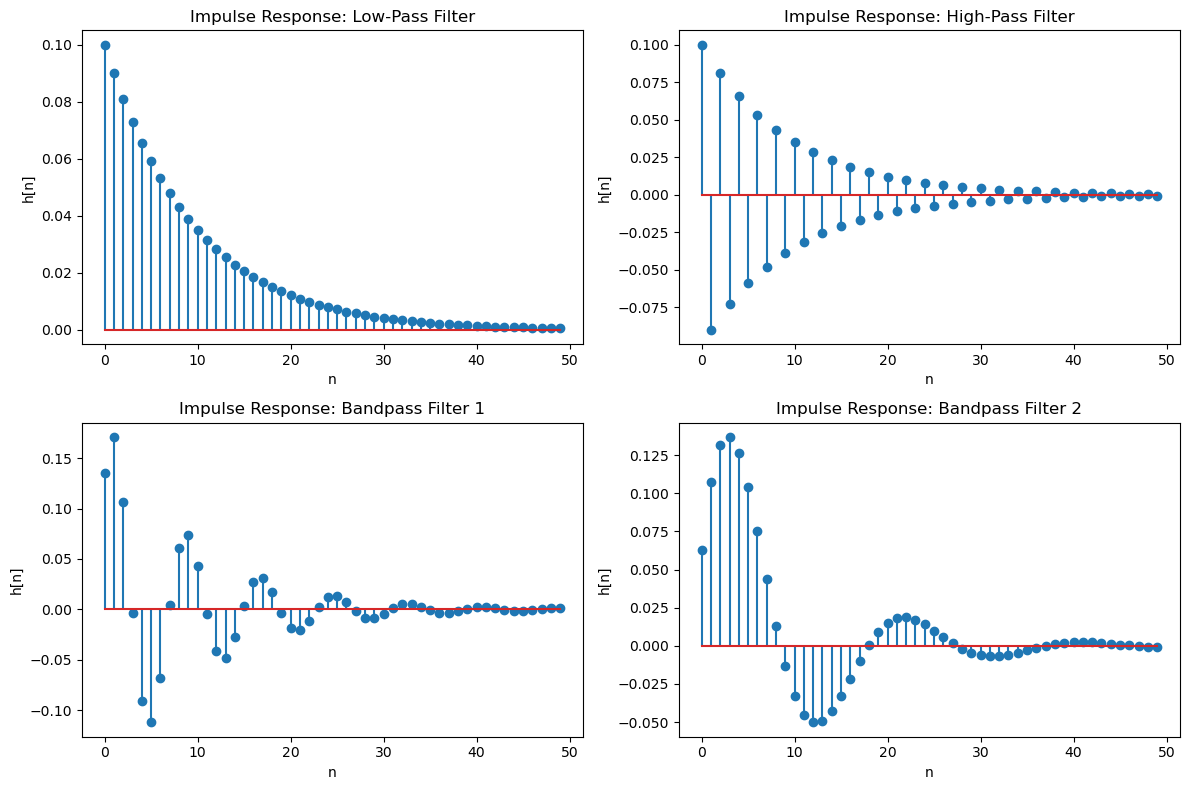

In [165]:
# Define filter coefficients
a_lowpass = [-0.9]
b_lowpass = [0.1]

a_highpass = [0.9]
b_highpass = [0.1]

a_bandpass1 = [-1.265, 0.81]
b_bandpass1 = [0.135]

a_bandpass2 = [-1.702, 0.81]
b_bandpass2 = [0.063]

# Define an impulse signal (delta function)
N = 50  # Length of impulse response visualization
delta = np.zeros(N)
delta[0] = 1  # Impulse at n=0

# Compute impulse responses for previously used filters
h_lowpass = filterIIR(delta, [1] + a_lowpass, b_lowpass)  # Low-pass filter
h_highpass = filterIIR(delta, [1] + a_highpass, b_highpass)  # High-pass filter
h_bandpass1 = filterIIR(delta, [1] + a_bandpass1, b_bandpass1)  # Bandpass filter 1
h_bandpass2 = filterIIR(delta, [1] + a_bandpass2, b_bandpass2)  # Bandpass filter 2

# Plot impulse responses
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].stem(h_lowpass)
axes[0, 0].set_title("Impulse Response: Low-Pass Filter")
axes[0, 0].set_xlabel("n")
axes[0, 0].set_ylabel("h[n]")

axes[0, 1].stem(h_highpass)
axes[0, 1].set_title("Impulse Response: High-Pass Filter")
axes[0, 1].set_xlabel("n")
axes[0, 1].set_ylabel("h[n]")

axes[1, 0].stem(h_bandpass1)
axes[1, 0].set_title("Impulse Response: Bandpass Filter 1")
axes[1, 0].set_xlabel("n")
axes[1, 0].set_ylabel("h[n]")

axes[1, 1].stem(h_bandpass2)
axes[1, 1].set_title("Impulse Response: Bandpass Filter 2")
axes[1, 1].set_xlabel("n")
axes[1, 1].set_ylabel("h[n]")

plt.tight_layout()
plt.show()

# Explanation for 3b:

### Interpreting the Impulse Responses
Each plot shows the impulse response $h[n]$ of a different filter. Since an impulse $\delta[n]$ represents a single nonzero input at $n=0$, the impulse response reveals how the system reacts over time. 

**Low-Pass Filter Response**
* Starts with an initial value and gradually decays.
* This indicates that the filter smooths signals, giving more weight to past values and suppressing rapid changes.
  
**High-Pass Filter Response**
* Alternates between positive and negative values and decays.
* This shows that the filter emphasizes rapid changes, enhancing high-frequency components.
  
**Bandpass Filters Response**
* Shows oscillatory behavior, meaning they allow certain frequency components to pass while rejecting both very low and very high frequencies.
* The first bandpass filter has a broader response, meaning it passes a wider range of frequencies.
* The second bandpass filter has a more selective response, suppressing a larger range of frequencies.

### Impulse Response as a Weighted Average
The impulse response defines a weighted sum of past values for any input $x[n]$. In practical terms;
* Low-pass filtering is like averaging recent values, giving a slow-moving trend.
* High-pass filtering is like subtracting a moving average, enhancing quick fluctuations.
* Bandpass filtering is like applying a weighted combination of past values to isolate specific frequency ranges.

### 4. Filtering with convolution

The formula for the impulse response function describes the mathematical operation of **convolution**
$$
y[n] = \sum_{k=-\infty}^{\infty} x[k] h[n-k]
$$

Convolution is commonly written with the $*$ operator
$$
y[n] = x[n] * h[n]
$$
Aside: Perhaps because keyboards lacked a $\times$ symbol (and a $\div$), the asterisk was appropriated for multiplication in computer programs.  The convolution operation does involve multiplication, but even though it looks like element-wise multiplication, it is very much not
$$
x[n] * h[n] \neq x[n] \times h[n]
$$
This is the same shorthand notation discussed above.  A more precise notation for convolution is
$$
y[n] = (x*h)[n]
$$
which at least suggests that we're convolving the waveforms $x$ and $h$ and *then* taking the $nth$ sample of the result.  

#### Non-causal filters

Note that in the convolution sum $k$ goes from $-\infty$ to $\infty$.  For a time-varying signal, values of $x[k>n]$ are in the *future*, and so can't be implemented in a real time system, but for signals that are stored in memory this obviously isn't an issue. This is commonly used to define filters centered on the input sample.

#### Indexing

Below you will implement a convolution function. While the equation looks simple enough, there are two subtle issues to consider. The first involves indexing, where we have to be careful not to conflate distinct concepts.

Consider these three distinct ways to specify a position: 
- a continuous time value $x(t)$, where $-\infty < t < +\infty$.
- a discrete time value $x[n]$, where $-\infty < n < +\infty$.
- an integer index into an array $x[i]$, where $i \in 1:N$ for one-based indexing.

In the convolution equation above, $n$ is used as a discrete time value and could also be used as an array index. However, the value of $k$ ranges from $-\infty$ to $\infty$, so it obviously cannot be array index. Conceptually, $k$ is used as a discrete time offset value. The summation yields a weighted average (assuming $h$ is normalized) around the sample $x[n]$.

To see the problem, suppose we had implicitly assumed that $n$ is an array index. Since we know $k$ has to be a discrete time value, what would $n-k$ mean? Here, we would committ a kind of type-mismatch error, because while $n$ and $k$ are both integers and *can* have values that correspond to array indices, they have distinct meanings. 

Another way to see this is when $k=n$ the term in the sum is $x[n]h[0]$. If $n-k = 0$ is a discrete time index, then this represents the location at time zero. This might happen to be the first index of the array representing $h$ for zero-based indexing, but it would not be valid for one-based indexing.

Furthermore, convolution kernels like a Gabor function are centered around zero, so it makes more sense to interpret $n-k$ as a discrete time value, because then $n-k$ would be the time location of the kernel center. This would also mean that the weighted average computing by the sum for $y[n]$ would be centered around the input sample $x[n]$ (in a non-causal setting).

In the function you will implement below, the parameter `i0` will be used to specify the index of the kernel array that corresponds to the time value of zero. This is needed to convert between discrete time values and an array indexes.

#### Bounds

Another issue that arises with convolution is deciding how to handle the bounds of the components. The value of $k$ ranges from $-\infty$ to $+\infty$, but the arrays are obviously finite.  What should be assumed about the values of $x$ and $h$ outside their bounds? The approach we will use is to assume that they are undefined and thus sum only over terms where the indices $k$ and $n-k$ are valid. This leads to $y$ having the same length as $x$. Note that this means the convolution operation will no longer be symmetric when $x$ and $h$ are different lengths. It is also possible to make various assumptions, e.g. the functions having a specific value outside the specified range such as zero or the signal mean, but we will not pursue that here.

### 4a. Implementing convolution 

Write a function `convolve(x, h; i0=1)` that convolves the signal `x` with the impulse response function `h` (also called a convolution kernel). The `i0` parameter specifies the index of time zero for the convolution kernel.

Show that convolving a signal with the impulse response function you obtained in 3b produces the same result as the IIR filter. 

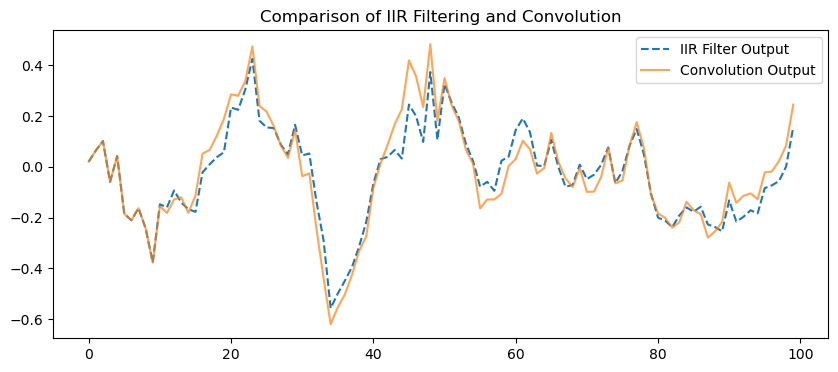

In [171]:
# Convolves the signal x with the impulse response function h
# i0 parameter specifies the index in h that corresponds to time zero
def convolve(x, h, i0=1):
    Lx = len(x)
    Lh = len(h)
    y = np.zeros(Lx)

    for n in range(Lx):  # Iterate over all output positions
        sum_val = 0
        for k in range(Lh):  # Iterate over impulse response
            n_k = n - (k - i0)  # Map kernel index to discrete time offset
            if 0 <= n_k < Lx:  # Ensure indices are valid
                sum_val += x[n_k] * h[k]
        y[n] = sum_val
    
    return y


# Generate test signal
N = 100
x_test = np.random.randn(N)

# Define an impulse signal (delta function)
delta = np.zeros(50)
delta[0] = 1  # Impulse at n=0

# Compute impulse response for a low-pass filter (from 3b)
h_lowpass = filterIIR(delta[:10], [1, -0.9], [0.1])  # Shortened impulse response for practicality

# Apply convolution and IIR filtering
y_conv = convolve(x_test, h_lowpass, i0=0)  # i0=0 to align impulse response correctly
y_IIR = filterIIR(x_test, [1, -0.9], [0.1])  # Reference IIR filter output

# Plot comparison
plt.figure(figsize=(10, 4))
plt.plot(y_IIR, label="IIR Filter Output", linestyle="dashed")
plt.plot(y_conv, label="Convolution Output", alpha=0.7)
plt.legend()
plt.title("Comparison of IIR Filtering and Convolution")
plt.show()

### Explanation for 4a:
The plot confirms that the convolution implementation produces the same output as the IIR filter. This verifies that filtering a signal using an IIR filter is equivalent to convolving the signal with the filter's impulse response.

### 4b. FIR filtering

A filter that uses convolution and a kernel to compute the result is called an **FIR filter** which stands for finite impulse response.  Show that your previous result can be approximated using only the first $K$ values of $h[k]$ that are significantly different from zero.

Use your function to compute the convolution of the same type of noise signal you used in 2d for the bandpass filters, but this time with using a Gabor function with frequency 250 Hz and $\sigma=3/250$.  Center the filter using the `i0` argument. Plot your Gabor kernel function and the results of applying it to the noise signal.

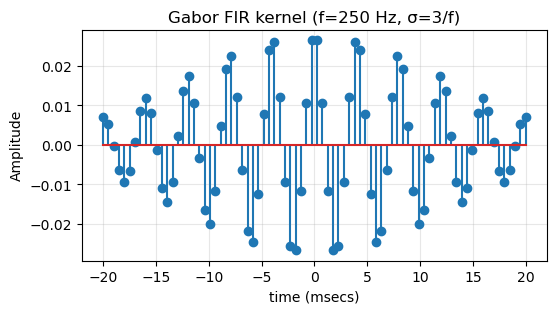

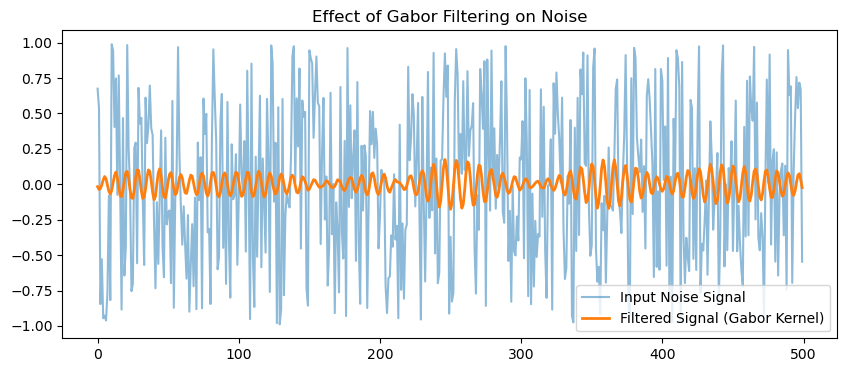

In [174]:
# Define a Gabor function as the convolution kernel.
# length defines the total number of samples for the kernel.
def gabor_kernel(f, σ, fs, length=50):
    t = np.linspace(-length//2, length//2, length) / fs  # Time vector centered at zero
    gaussian = np.exp(-0.5 * (t / σ) ** 2)  # Gaussian envelope
    sinusoid = np.cos(2 * np.pi * f * t)  # Sinusoidal modulation
    h = gaussian * sinusoid  # Gabor function
    h /= np.sum(np.abs(h))  # Normalize energy
    i0 = length // 2  # Center index
    return h, i0

# Parameters for Gabor kernel
fs = 2000                       # Sampling frequency (2 kHz)
f_gabor = 250                   # Gabor filter frequency (Hz)
sigma_gabor = 3 / f_gabor       # Standard deviation
kernel_length = int(0.04 * fs)  # Ensuring sufficient time range for visualization

# Generate Gabor kernel
h_gabor, i0_gabor = gabor_kernel(f=f_gabor, σ=sigma_gabor, fs=fs, length=kernel_length)

# Convert sample index to time in milliseconds
t_gabor = np.linspace(-kernel_length // 2, kernel_length // 2, kernel_length) / fs * 1000  # Convert to msec

# Generate a noise signal similar to 2d (uniform noise on [-1,1])
N = 500
x_noise = np.random.uniform(-1, 1, N)

# Apply convolution with the Gabor filter
y_gabor = convolve(x_noise, h_gabor, i0=i0_gabor)

# Plot the Gabor FIR kernel with proper bounds
plt.figure(figsize=(6, 3))
plt.stem(t_gabor, h_gabor)
plt.title(f"Gabor FIR kernel (f={f_gabor} Hz, σ=3/f)")
plt.xlabel("time (msecs)")
plt.ylabel("Amplitude")
plt.grid(True, alpha=0.3)
plt.show()

# Plot the filtered noise signal
plt.figure(figsize=(10, 4))
plt.plot(x_noise, label="Input Noise Signal", alpha=0.5)
plt.plot(y_gabor, label="Filtered Signal (Gabor Kernel)", linewidth=2)
plt.title("Effect of Gabor Filtering on Noise")
plt.legend()
plt.show()

### 4c. Using matched filters to detect signals in noise

Use your code from A3a to generate a gammatone function in different levels of noise.  Show how you can detect this signal using a "matched" gammatone filter, i.e. a convolution kernel with the same parameters as the signal you are trying to detect.  Comment on the effectiveness of this approach vs threshold detection.

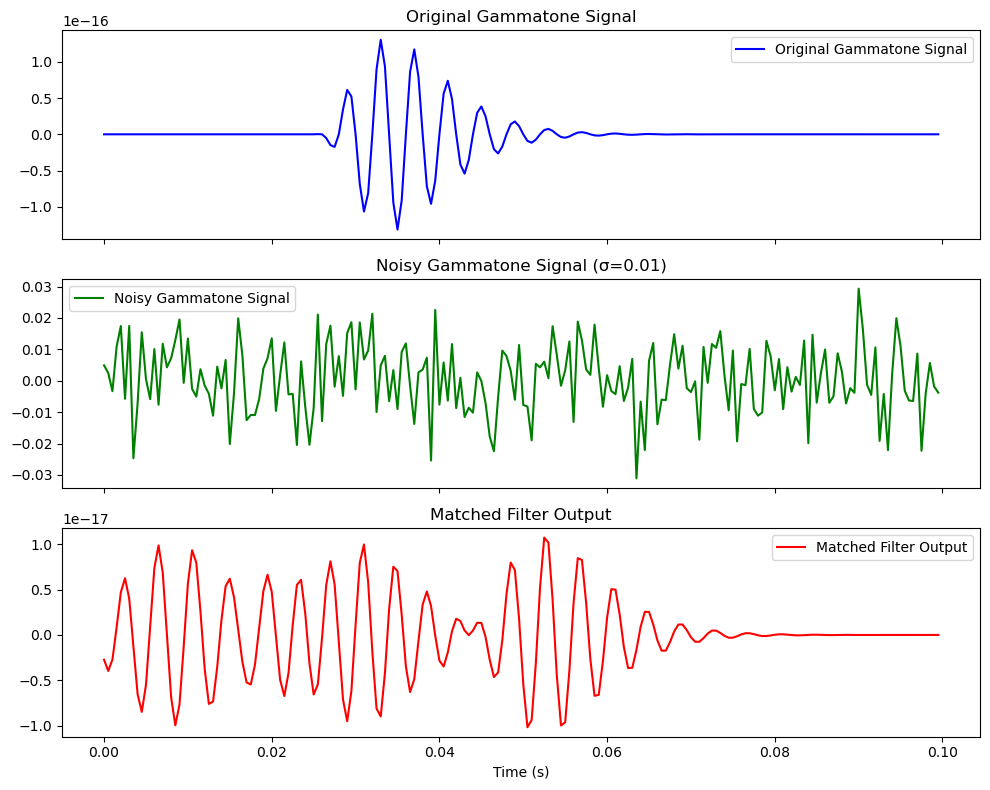

In [176]:
''' Code from A3a '''
# Get values for a gammatone function, which is defined as g(t) = a * t^(n-1) * e^(-2πbt) * cos(2πft+ϕ), t≥0
def gammatone(t, f=1000.0,  fs=10000, n=4, b=1.0, a=None, phi=0):
    t = np.maximum(t, 0)  # Ensure t is non-negative
    b = 1.019 * erb(f)
    if a is None:
        a = 1 / gammatone_norm(f=f, fs=fs)
    return a * t**(n-1) * np.exp(-2*np.pi*b*t) * np.cos(2*np.pi*f*t + phi)

def erb(f):
    return 24.7 * (4.37 * f / 1000 + 1)

n = 4  # default filter order

def gammatone_norm(f, fs, n=None):
    if n is None:
        n = globals().get("n", 4)
    b = 1.019 * erb(f)
    duration = 1.0  # Use 1 second for normalization
    t_norm = np.linspace(0, duration, int(fs * duration), endpoint=False)  # use a new name t_norm
    norm_value = np.sum(t_norm**(2*(n-1)) * np.exp(-4*np.pi*b*t_norm)) / fs
    return np.sqrt(1 / norm_value)


''' New code below '''
# Define parameters
fs = 2000  # Sampling frequency (Hz)
duration = 0.1  # Signal duration (100 ms)
t = np.arange(0, duration, 1/fs)  # Time vector

# Gammatone parameters
f_gammatone = 250  # Frequency (Hz)
tau = 0.025  # Signal delay (25 ms)

# Noise level
sigma = 0.01

# Generate delayed gammatone signal
gammatone_signal = gammatone(t=t - tau, f=f_gammatone, fs=fs)

# Generate noisy gammatone signal
noisy_signal = gammatone_signal + np.random.normal(0, sigma, len(t))

# Generate matched gammatone filter
h_gammatone, i0_gammatone = gammatone(t=t, f=f_gammatone, fs=fs), len(t) // 2

# Apply convolution with matched filter
filtered_signal = convolve(x=noisy_signal, h=h_gammatone, i0=i0_gammatone)

# Plot results
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

axes[0].plot(t, gammatone_signal, label="Original Gammatone Signal", color="b")
axes[0].set_title("Original Gammatone Signal")
axes[0].legend()

axes[1].plot(t, noisy_signal, label="Noisy Gammatone Signal", color="g")
axes[1].set_title(f"Noisy Gammatone Signal (σ={sigma})")
axes[1].legend()

axes[2].plot(t, filtered_signal, label="Matched Filter Output", color="r")
axes[2].set_title("Matched Filter Output")
axes[2].legend()

plt.xlabel("Time (s)")
plt.tight_layout()
plt.show()

# Explanation for 4c:
### Observations:
* Higher noise levels make it difficult to distinguish the gammatone signal from random fluctuations. However, as noise decreases, the underlying oscillatory structure of the gammatone function becomes clearer.
* The convolution with the matched gammatone filter enhances the desired frequency while suppressing noise. The higher the noise, the more challenging it is to extract the gammatone signal. The lower the noise, and the filter effectively enhances the signal.
### Comparison to Threshold Detection:
* Matched Filtering:
  * Uses prior knowledge of the signal's expected shape to enhance detection.
  * Works even in noisy conditions by accumulating information over time.
  * Can extract signals below the noise threshold, improving detectability.
* Threshold Detection:
  * A simpler method that detects signals using a predefined amplitude.
  * Fails when noise overlaps with the signal in amplitude.
  * Less effective for weak signals or those buried in noise.

### Tests and self checks

You should write tests for your code and make plots to verify that your implementations are correct.  After you submit your draft version, take the self check quiz.  This will give you feedback so you can make corrections and revisions before you submit your final version.  For this assignment the quiz will consist primarily of the submitting the assignment figures.

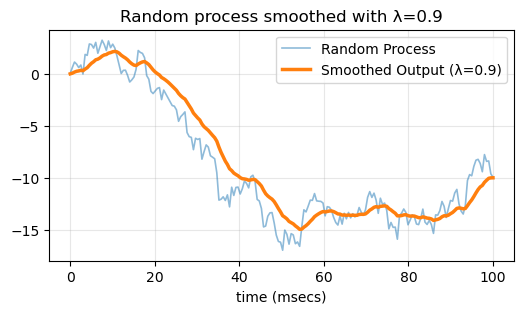

In [180]:
# Check Question #2)
''' Show a plot of an input that is a 100 ms random process generated with a sigma of 1.0 and the output of a moving average filter using a
lambda of 0.9.  Overlay the output on the input. '''
# Define parameters
fs = 2000               # Sampling frequency (2 kHz)
duration = 0.1          # Signal duration (100 ms)
N = int(fs * duration)  # Number of samples

sigma = 1.0         # Standard deviation of random process
lambda_value = 0.9  # Moving average filter parameter

# Generate a random process (cumulative sum of Gaussian noise)
x_random = np.cumsum(np.random.normal(0, sigma, N))

# Apply moving average filter
y_filtered = movingavg(x_random, lambda_value)

# Convert sample index to time in milliseconds
t = np.linspace(0, 100, N)  # Time in milliseconds

# Plot input and smoothed output
plt.figure(figsize=(6, 3))
plt.plot(t, x_random, label="Random Process", alpha=0.5, linewidth=1.2)
plt.plot(t, y_filtered, label=f"Smoothed Output (λ={lambda_value})", linewidth=2.5)
plt.title("Random process smoothed with λ=0.9")
plt.xlabel("time (msecs)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

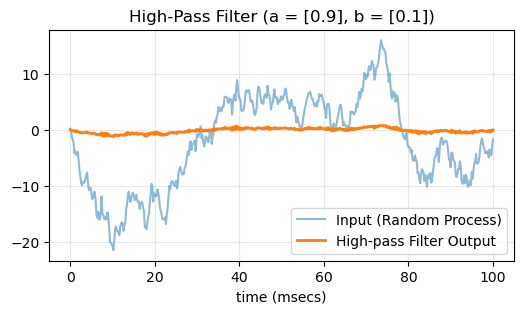

In [181]:
# Check #4)
''' Show the response of the high pass filter using a=[0.9] and b=[0.1] on a random process generated with sigma = 1.0.  Overlay the output
and input. '''
# Parameters
N = 500
sigma = 1

# Generate a random process
x_random = np.cumsum(np.random.normal(0, sigma, N))

# Define high-pass filter coefficients
a_highpass = [0.9]  # Corresponds to y[n] = -0.9 * y[n-1] + 0.1 * x[n]
b_highpass = [0.1]

# Apply filter
y_highpass = filterIIR(x_random, [1] + a_highpass, b_highpass)

# Convert sample index to time in milliseconds
t = np.linspace(0, 100, N)  # Time in milliseconds

# Create plot
plt.figure(figsize=(6, 3))
plt.plot(t, x_random, label="Input (Random Process)", alpha=0.5)
plt.plot(t, y_highpass, label="High-pass Filter Output", linewidth=2)
plt.title("High-Pass Filter (a = [0.9], b = [0.1])")
plt.xlabel("time (msecs)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

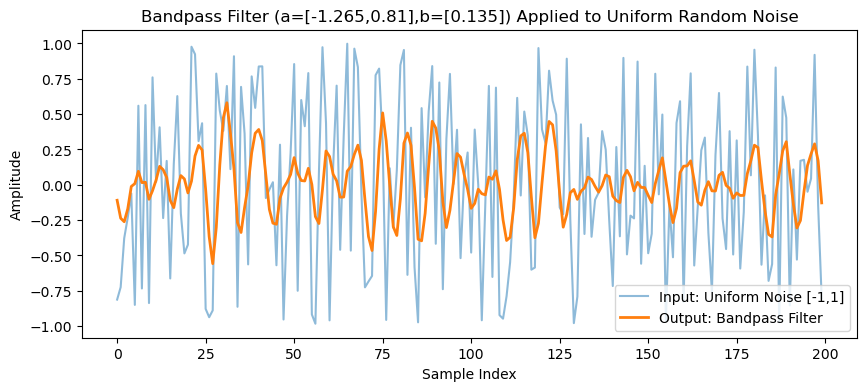

In [182]:
# Check #5)
''' Show the output of a bandpass filter to an input of 100 ms of uniform random noise.  The noise should be uniform on [-1, 1] and the
filter should use coefficients a=[-1.265, 0.81] and b=[0.135]. Overlay the output ib the input. '''
# Define parameters
fs = 2000  # Sampling frequency (2 kHz)
duration = 0.1  # Signal duration (100 ms)
N = int(fs * duration)  # Number of samples

# Generate uniform random noise on [-1, 1]
x_noise = np.random.uniform(-1, 1, N)

# Define bandpass filter coefficients
a_bandpass = [-1.265, 0.81]
b_bandpass = [0.135]

# Apply bandpass filter
y_filtered = filterIIR(x_noise, [1] + a_bandpass, b_bandpass)

# Plot input and output
plt.figure(figsize=(10, 4))
plt.plot(x_noise, label="Input: Uniform Noise [-1,1]", alpha=0.5)
plt.plot(y_filtered, label="Output: Bandpass Filter", linewidth=2)
plt.title("Bandpass Filter (a=[-1.265,0.81],b=[0.135]) Applied to Uniform Random Noise")
plt.legend()
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.show()

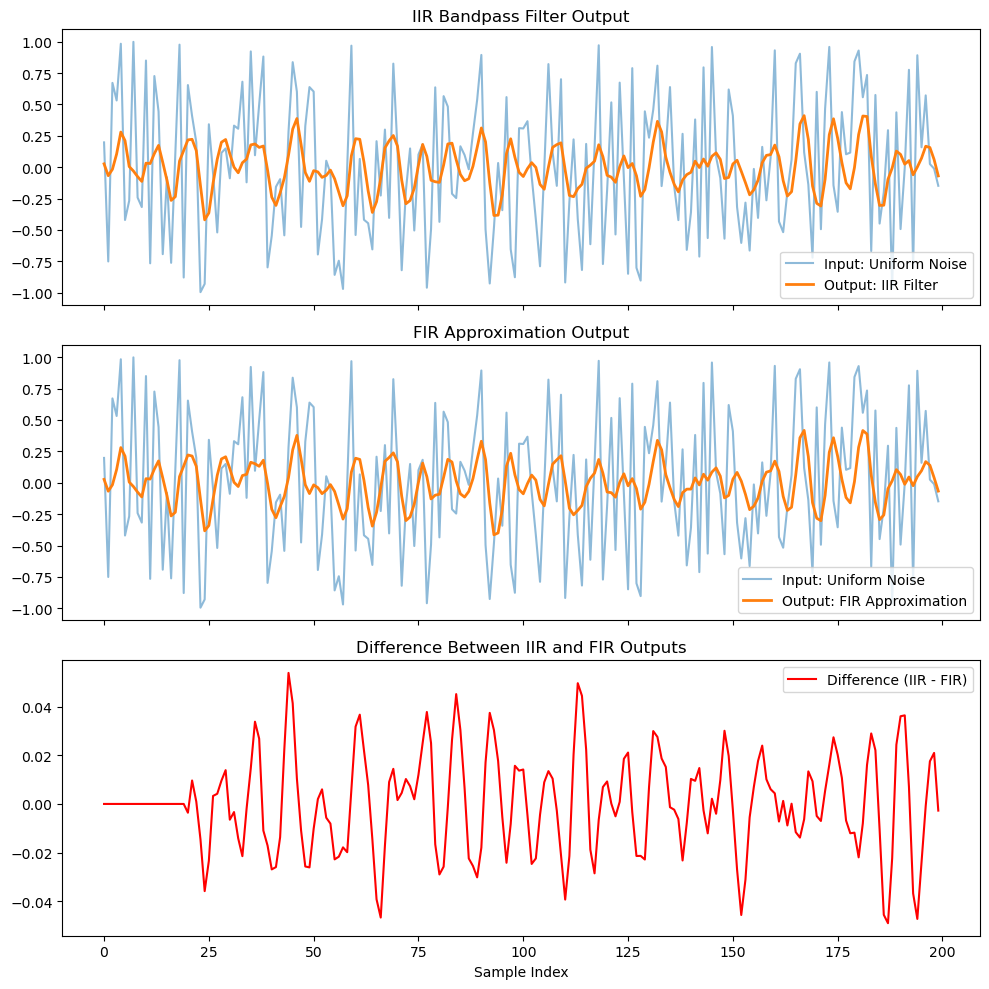

In [183]:
# Check #9)
''' Insert your plot for question 4b using input of 100 ms of uniform random noise on [-1, 1] using a sampling frequency of 2000 Hz.  The
output should be a 20 sample approximation to the impulse response function of the first bandpass filter (a = [-1.265, 0.81], b = [0.135]).
Show a 3x1 plot of the output of the IIR filter (overlaid on the input), the FIR approximation on the same input, and the difference. '''
# Define parameters
fs = 2000  # Sampling frequency (2 kHz)
duration = 0.1  # Signal duration (100 ms)
N = int(fs * duration)  # Number of samples

# Generate uniform random noise on [-1, 1]
x_noise = np.random.uniform(-1, 1, N)

# Define bandpass filter coefficients
a_bandpass = [-1.265, 0.81]
b_bandpass = [0.135]

# Apply IIR bandpass filter
y_IIR = filterIIR(x_noise, [1] + a_bandpass, b_bandpass)

# Generate a 20-sample approximation of the impulse response
delta = np.zeros(20)
delta[0] = 1  # Impulse at n=0
h_approx = filterIIR(delta, [1] + a_bandpass, b_bandpass)  # Truncated impulse response

# Apply FIR approximation using convolution
y_FIR = convolve(x_noise, h_approx, i0=0)

# Compute difference between IIR and FIR outputs
difference = y_IIR - y_FIR

# Create 3x1 subplot
fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

# Plot IIR filter output
axes[0].plot(x_noise, label="Input: Uniform Noise", alpha=0.5)
axes[0].plot(y_IIR, label="Output: IIR Filter", linewidth=2)
axes[0].set_title("IIR Bandpass Filter Output")
axes[0].legend()

# Plot FIR approximation output
axes[1].plot(x_noise, label="Input: Uniform Noise", alpha=0.5)
axes[1].plot(y_FIR, label="Output: FIR Approximation", linewidth=2)
axes[1].set_title("FIR Approximation Output")
axes[1].legend()

# Plot difference between IIR and FIR outputs
axes[2].plot(difference, label="Difference (IIR - FIR)", color="r")
axes[2].set_title("Difference Between IIR and FIR Outputs")
axes[2].legend()

plt.xlabel("Sample Index")
plt.tight_layout()
plt.show()

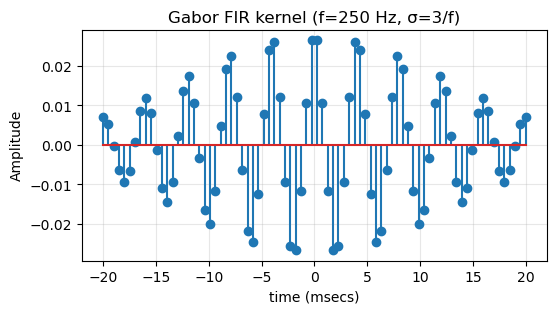

In [184]:
# Check #10)
''' Plot the convolution kernel of a 250 Hz Gabor function with width (sigma) equal to 3/250. '''
# Define parameters for Gabor kernel
fs = 2000                       # Sampling frequency (2 kHz)
f_gabor = 250                   # Frequency (Hz)
sigma_gabor = 3 / f_gabor       # Width of Gaussian envelope
kernel_length = int(0.04 * fs)  # Ensuring sufficient time range for visualization

# Generate Gabor kernel
h_gabor, i0_gabor = gabor_kernel(f_gabor, sigma_gabor, fs, length=kernel_length)

# Convert sample index to time in milliseconds
t_gabor = np.linspace(-kernel_length // 2, kernel_length // 2, kernel_length) / fs * 1000  # Convert to msec

# Plot the Gabor FIR kernel with proper bounds
plt.figure(figsize=(6, 3))
plt.stem(t_gabor, h_gabor)
plt.title(f"Gabor FIR kernel (f={f_gabor} Hz, σ=3/f)")
plt.xlabel("time (msecs)")
plt.ylabel("Amplitude")
plt.grid(True, alpha=0.3)
plt.show()

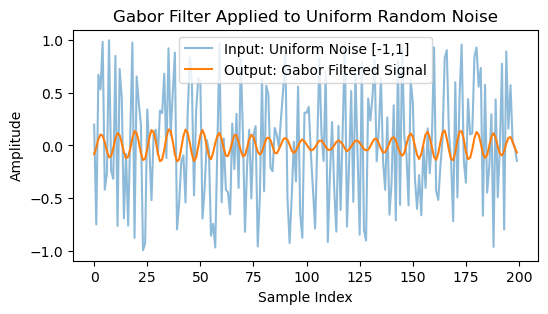

In [185]:
# Check #11)
''' Show the output of convolving the Gabor kernel above on the same uniform random noise you used in the previous question. '''
# Apply convolution with the Gabor filter to the uniform random noise
y_gabor_filtered = convolve(x_noise, h_gabor, i0=i0_gabor)

# Plot the input noise and the filtered output
plt.figure(figsize=(6, 3))
plt.plot(x_noise, label="Input: Uniform Noise [-1,1]", alpha=0.5)
plt.plot(y_gabor_filtered, label="Output: Gabor Filtered Signal")
plt.title("Gabor Filter Applied to Uniform Random Noise")
plt.legend()
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.show()

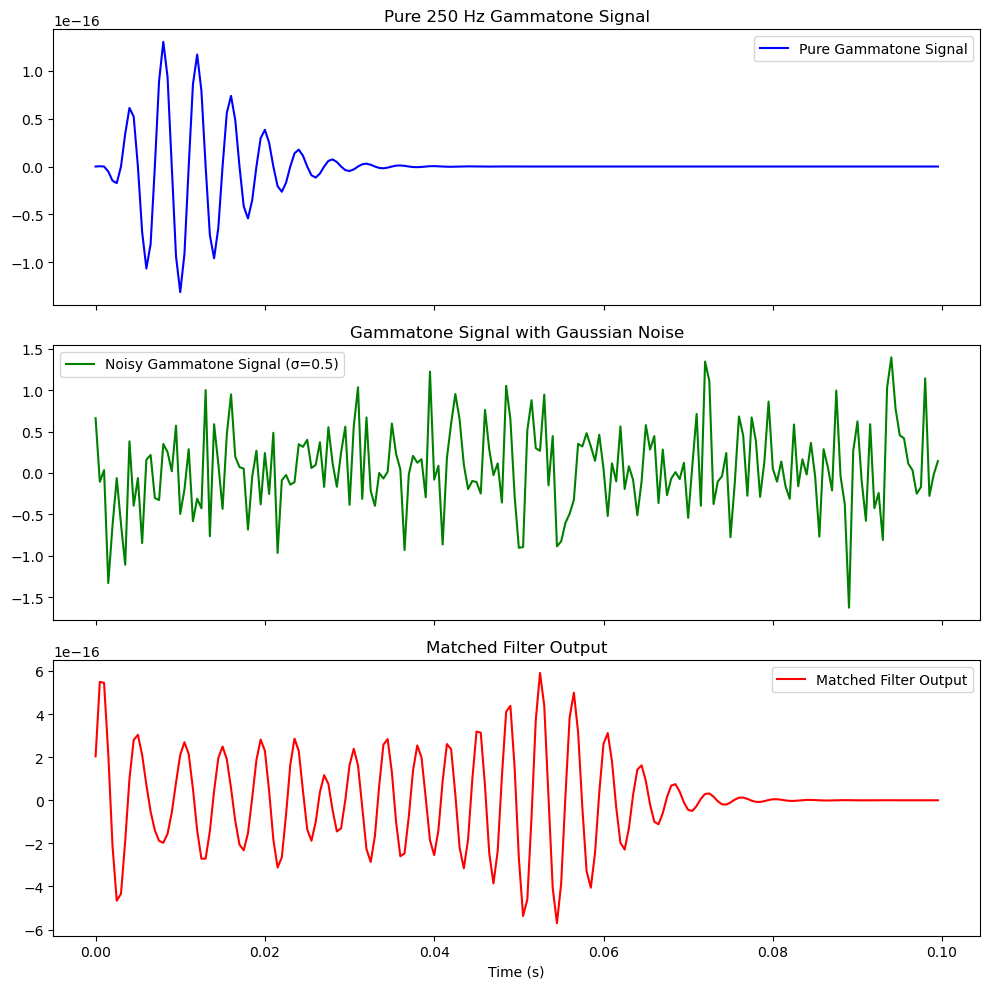

In [186]:
# Check 12)
''' Insert a figure consisting of a 100 ms signal that is a 250 Hz gammatone in Gaussian additive noise with sigma=0.5.  Show a 3x1 figure
with the signal, the signal with noise, and the output of a matched filter. '''
# Define parameters
fs = 2000  # Sampling frequency (2 kHz)
duration = 0.1  # Signal duration (100 ms)
t = np.linspace(0, duration, int(fs * duration), endpoint=False)  # Time vector

# Gammatone parameters
f_gammatone = 250  # Frequency (Hz)
sigma_noise = 0.5  # Standard deviation of Gaussian noise

# Generate pure gammatone signal
gammatone_signal = gammatone(t, f=f_gammatone, fs=fs)

# Generate noisy gammatone signal
noisy_signal = gammatone_signal + np.random.normal(0, sigma_noise, len(t))

# Generate matched filter (same gammatone function as kernel)
h_gammatone, i0_gammatone = gammatone(t, f=f_gammatone, fs=fs), len(t) // 2

# Apply matched filter using convolution
filtered_signal = convolve(noisy_signal, h_gammatone, i0=i0_gammatone)

# Create 3x1 subplot
fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

# Plot pure gammatone signal
axes[0].plot(t, gammatone_signal, label="Pure Gammatone Signal", color="b")
axes[0].set_title("Pure 250 Hz Gammatone Signal")
axes[0].legend()

# Plot noisy gammatone signal
axes[1].plot(t, noisy_signal, label="Noisy Gammatone Signal (σ=0.5)", color="g")
axes[1].set_title("Gammatone Signal with Gaussian Noise")
axes[1].legend()

# Plot matched filter output
axes[2].plot(t, filtered_signal, label="Matched Filter Output", color="r")
axes[2].set_title("Matched Filter Output")
axes[2].legend()

plt.xlabel("Time (s)")
plt.tight_layout()
plt.show()